# <center>Practical 8: Learning</center>

In [267]:
import numpy as np
from matplotlib import pyplot as plt
import torch
torch.manual_seed(3407) #https://arxiv.org/abs/2109.08203
np.random.seed(3407)

# Exercise 1: A neural network regression problem

We will be using pytorch to build a simple neural network model. 

In [268]:
class NeuralNetwork(torch.nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(NeuralNetwork, self).__init__()
        self.fc1 = torch.nn.Linear(input_size, hidden_size)
        self.relu = torch.nn.ReLU()
        self.fc2 = torch.nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

Let's generate some training data from a differential drive robot motion model. We'll pretend we collected this from a real robot.

In [269]:
def diff_drive(x,u,dt=0.1):
    x_dot = np.zeros((3,1))
    x_dot[0] = u[0] * np.cos(x[2])
    x_dot[1] = u[0] * np.sin(x[2])
    x_dot[2] = u[1]
    return x.copy() + x_dot*dt

In [270]:
transitions = []
for j in range(1000):
    x_pre = np.random.randn(3,1) #Start the robot in random places
    u = np.random.randn(2,1) #Random control inputs
    x = diff_drive(x_pre,u)
    transitions.append([x_pre,u,x]) 

In [271]:
# Create a pytorch dataset from the transitions
class TransitionDataset(torch.utils.data.Dataset):
    def __init__(self, transitions):
        self.transitions = transitions

    def __len__(self):
        return len(self.transitions)

    def __getitem__(self, idx):
        x, u, x_next = self.transitions[idx]
        return torch.tensor(np.hstack([x.squeeze(), u.squeeze()]), dtype=torch.float32), torch.tensor(x_next.squeeze(), dtype=torch.float32)

In [272]:
dataloaders = torch.utils.data.DataLoader(TransitionDataset(transitions), batch_size=32, shuffle=True)
model = NeuralNetwork(input_size=5, hidden_size=64, output_size=3)
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [273]:
for epoch in range(100):  # Number of epochs
    for i, (inputs, targets) in enumerate(dataloaders):
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

    print(f'Epoch [{epoch+1}/100], Loss: {loss.item():.4f}')

Epoch [1/100], Loss: 0.3870
Epoch [2/100], Loss: 0.3128
Epoch [3/100], Loss: 0.0782
Epoch [4/100], Loss: 0.0564
Epoch [5/100], Loss: 0.0181
Epoch [6/100], Loss: 0.0190
Epoch [7/100], Loss: 0.0120
Epoch [8/100], Loss: 0.0076
Epoch [9/100], Loss: 0.0084
Epoch [10/100], Loss: 0.0068
Epoch [11/100], Loss: 0.0058
Epoch [12/100], Loss: 0.0080
Epoch [13/100], Loss: 0.0094
Epoch [14/100], Loss: 0.0073
Epoch [15/100], Loss: 0.0046
Epoch [16/100], Loss: 0.0048
Epoch [17/100], Loss: 0.0033
Epoch [18/100], Loss: 0.0042
Epoch [19/100], Loss: 0.0013
Epoch [20/100], Loss: 0.0025
Epoch [21/100], Loss: 0.0031
Epoch [22/100], Loss: 0.0043
Epoch [23/100], Loss: 0.0065
Epoch [24/100], Loss: 0.0033
Epoch [25/100], Loss: 0.0014
Epoch [26/100], Loss: 0.0029
Epoch [27/100], Loss: 0.0020
Epoch [28/100], Loss: 0.0042
Epoch [29/100], Loss: 0.0027
Epoch [30/100], Loss: 0.0015
Epoch [31/100], Loss: 0.0020
Epoch [32/100], Loss: 0.0014
Epoch [33/100], Loss: 0.0025
Epoch [34/100], Loss: 0.0020
Epoch [35/100], Loss: 0

In [274]:
# Now let's test the model on some new data
test_transitions = []
for j in range(32):
    x_pre = np.random.randn(3,1) #Start the robot in random places
    u = np.random.randn(2,1) #Random control inputs
    x = diff_drive(x_pre,u)
    test_transitions.append([x,u,x_pre]) 
    
test_dataset = TransitionDataset(test_transitions)
test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

for i, (inputs, targets) in enumerate(test_dataloader):
    outputs = model(inputs)
    loss = criterion(outputs, targets)
    print(f'Test Batch [{i+1}], Loss: {loss.item():.4f}')

Test Batch [1], Loss: 0.0210


That looks good. The test loss is low, and the training loss is similar.

# Exercise 2: Always test robot learning models in closed loop.

In [275]:
#Now lets use the model in a closed loop simulation, we'll compare with the true dynamics
x_true = np.zeros((3,1))
x_pred = np.zeros((3,1))
u = np.array([[1.0],[0.1]]) #Constant control input 
x_true_history = [x_true.copy()]
x_pred_history = [x_pred.copy()]
for t in range(100):
    x_true = diff_drive(x_true, u)
    x_pred_input = torch.tensor(np.hstack([x_pred.squeeze(), u.squeeze()]), dtype=torch.float32).unsqueeze(0)
    x_pred = model(x_pred_input).detach().numpy().reshape(3,1)
    x_true_history.append(x_true.copy())
    x_pred_history.append(x_pred.copy())
    
x_true_history = np.array(x_true_history)
x_pred_history = np.array(x_pred_history)
average_loss = np.mean(np.linalg.norm(x_true_history - x_pred_history, axis=1))


print(f'Average loss {average_loss:.4f}')

Average loss 2.8667


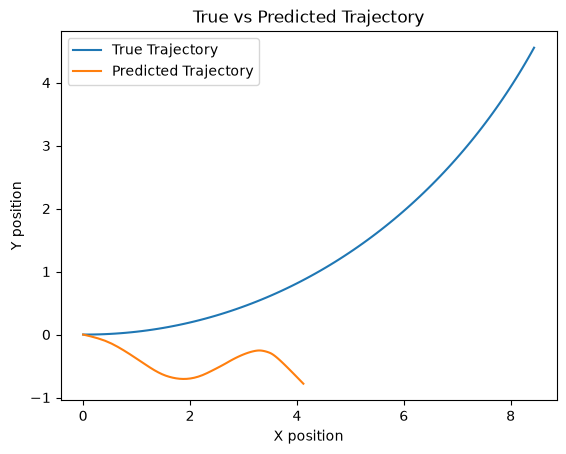

In [276]:
plt.figure()
plt.plot([x[0] for x in x_true_history], [x[1] for x in x_true_history], label='True Trajectory')
plt.plot([x[0] for x in x_pred_history], [x[1] for x in x_pred_history], label='Predicted Trajectory')
plt.xlabel('X position')
plt.ylabel('Y position')
plt.title('True vs Predicted Trajectory')
plt.legend()
plt.show()

Uh oh. What went wrong?

# Exercise 3: Behaviour cloning.

Lets teach a 2D point mass robot to drive along a lemiscate trajectory.

In [277]:
def point_mass(x,u,dt=0.1):
    x_dot = np.zeros((2,1))
    x_dot[0] = u[0]
    x_dot[1] = u[1]
    return x.copy() + x_dot*dt

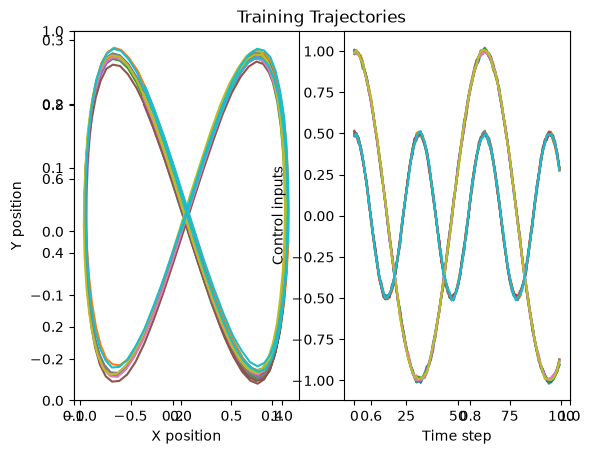

In [278]:
#Generate training data:

trajectories = []
for j in range(10):
    x = np.zeros((2,1)) #Start the robot at [0,0]
    # Generate controls to follow a lemiscate of gerono trajectory
    
    transitions = []
    for t in range(100):
        u = np.array([[np.cos(t/10.0)],[np.cos(2*t/10.0)/2.0]]) + 0.01*np.random.randn(2,1) #Add some noise to the controls
        x_next = point_mass(x,u)
        transitions.append(np.vstack([x,u]).T)
        x = x_next.copy()
    trajectories.append(np.vstack(transitions))
    
plt.figure()
plt.title('Training Trajectories')
plt.subplot(1,2,1)
for traj in trajectories:
    plt.plot([x[0] for x in traj], [x[1] for x in traj])
plt.xlabel('X position')
plt.ylabel('Y position')

plt.subplot(1,2,2)
for traj in trajectories:
    plt.plot([x[2] for x in traj],label='v')
    plt.plot([x[3] for x in traj],label='omega')
plt.xlabel('Time step')
plt.ylabel('Control inputs')
plt.show()
    

In [279]:
# Create a pytorch dataset from the transitions
class BCTransitionDataset(torch.utils.data.Dataset):    
    def __init__(self, trajectories):
        self.data = np.vstack(trajectories)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        x, u = self.data[idx][:2], self.data[idx][2:]
        return torch.tensor([x.squeeze()], dtype=torch.float32), torch.tensor([u.squeeze()], dtype=torch.float32)

In [280]:
bcdataloader = torch.utils.data.DataLoader(BCTransitionDataset(np.vstack(trajectories)), batch_size=32, shuffle=True)
model = NeuralNetwork(input_size=2, hidden_size=64, output_size=2)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = torch.nn.MSELoss()

In [281]:
for epoch in range(100):  # Number of epochs
    for i, (inputs, targets) in enumerate(bcdataloader):
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

    print(f'Epoch [{epoch+1}/100], Loss: {loss.item():.4f}')

Epoch [1/100], Loss: 0.2714
Epoch [2/100], Loss: 0.3334
Epoch [3/100], Loss: 0.2333
Epoch [4/100], Loss: 0.1945
Epoch [5/100], Loss: 0.1292
Epoch [6/100], Loss: 0.2063
Epoch [7/100], Loss: 0.1721
Epoch [8/100], Loss: 0.0844
Epoch [9/100], Loss: 0.1704
Epoch [10/100], Loss: 0.3501
Epoch [11/100], Loss: 0.1589
Epoch [12/100], Loss: 0.0643
Epoch [13/100], Loss: 0.0708
Epoch [14/100], Loss: 0.0337
Epoch [15/100], Loss: 0.2357
Epoch [16/100], Loss: 0.0943
Epoch [17/100], Loss: 0.0414
Epoch [18/100], Loss: 0.0952
Epoch [19/100], Loss: 0.0485
Epoch [20/100], Loss: 0.0397
Epoch [21/100], Loss: 0.0821
Epoch [22/100], Loss: 0.1987
Epoch [23/100], Loss: 0.0787
Epoch [24/100], Loss: 0.0183
Epoch [25/100], Loss: 0.0475
Epoch [26/100], Loss: 0.0923
Epoch [27/100], Loss: 0.0901
Epoch [28/100], Loss: 0.0880
Epoch [29/100], Loss: 0.0397
Epoch [30/100], Loss: 0.0591
Epoch [31/100], Loss: 0.1612
Epoch [32/100], Loss: 0.0871
Epoch [33/100], Loss: 0.0746
Epoch [34/100], Loss: 0.0874
Epoch [35/100], Loss: 0

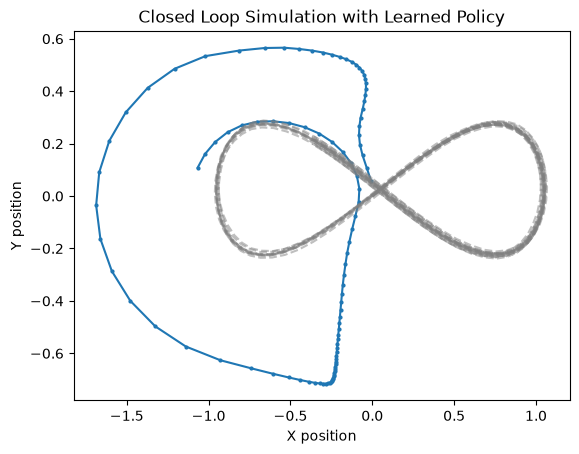

In [282]:
#Evaluate the model in closed loop simulation
x = np.zeros((2,1))
trajectory = []
for t in range(100):
    
    u = model(torch.tensor([x.squeeze()], dtype=torch.float32)).detach().numpy().reshape(2,1)
    
    x_new = point_mass(x,u)
    x = x_new.copy() 
    trajectory.append(x.copy())

plt.figure()
plt.title('Closed Loop Simulation with Learned Policy')
plt.plot([x[0] for x in trajectory], [x[1] for x in trajectory],ls='-', marker='o', markersize=2)
for traj in trajectories:
    plt.plot([x[0] for x in traj], [x[1] for x in traj],ls='--', alpha=0.5, color='gray')
plt.xlabel('X position')
plt.ylabel('Y position')
plt.show()

Uh oh. What went wrong?

Let's try a dmp instead.

In [283]:

class DMP:
    def __init__(self, n_bfs=20):
        self.n_bfs = n_bfs
        self.centers = np.linspace(0.0, 1.0, n_bfs)
        self.widths = np.ones(n_bfs) * 0.1

    def basis_function(self, phase):
        phase = np.atleast_1d(np.asarray(phase, dtype=np.float32))
        return np.exp(
            -0.5 * ((phase[:, None] - self.centers[None, :]) / self.widths[None, :]) ** 2
        )

    def train(self, values):
        phase = np.linspace(0.0, 1.0, len(values))
        y = np.asarray(values, dtype=np.float32).reshape(-1)

        psi = self.basis_function(phase)
        self.weights = np.linalg.lstsq(psi, y, rcond=None)[0]

    def reproduce(self, phase):
        phase = np.atleast_1d(np.asarray(phase, dtype=np.float32))
        psi = self.basis_function(phase)
        value = psi @ self.weights
        return value[0] if len(value) == 1 else value



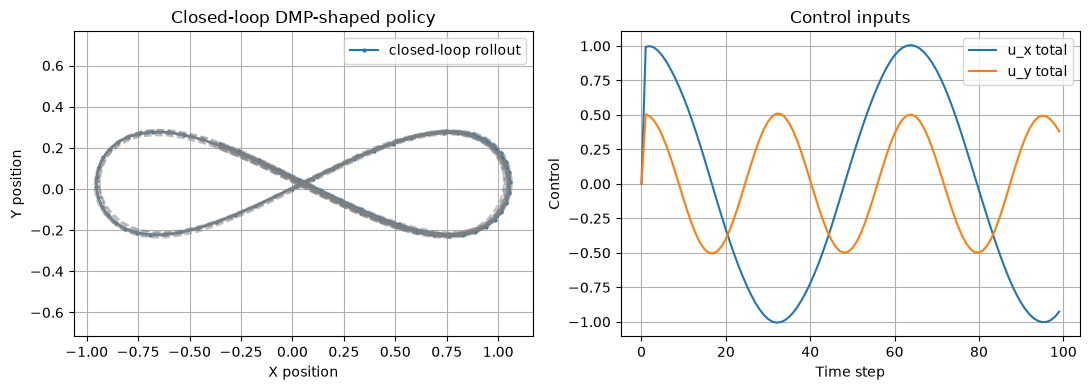

In [284]:
# ------------------------------------------------------------
# Fit DMP to demonstrated controls
# ------------------------------------------------------------
# Assumes each trajectory row is [x, y, ux, uy]
# If your columns mean [x, y, v, omega], rename accordingly.

dmp_x = DMP(n_bfs=20)
dmp_y = DMP(n_bfs=20)

dmp_x.train(np.array(trajectories[0])[:, 0])
dmp_y.train(np.array(trajectories[0])[:, 1])


# Evaluate the model in closed loop simulation
# ------------------------------------------------------------
# Closed-loop rollout
# ------------------------------------------------------------

x = np.zeros((2, 1))
trajectory = []
controls = []
dmp_controls = []
feedback_controls = []

prev_pd = None

k_track = 0        # stabilizing feedback gain

for t in range(100):
    phase = t / 99.0

    # Decaying phase: starts at 1, ends at 0.
    # This makes the DMP/feedforward term vanish at the end.
    s = 1-phase

    pd = np.array([
        dmp_x.reproduce(phase),
        dmp_y.reproduce(phase)
    ]).reshape(2, 1)
    
    if prev_pd is None:
        vd = np.zeros((2, 1))
    else:
        vd = (pd - prev_pd) / 0.1
        
    prev_pd = pd.copy()

    # DMP-shaped closed-loop controller
    u = vd + k_track*(pd - x)

    x = point_mass(x, u) #+ 0.01*np.random.randn(2, 1)

    trajectory.append(x.copy())
    controls.append(u.copy())
    
trajectory = np.array(trajectory).squeeze()
controls = np.array(controls).squeeze()

plt.figure(figsize=(11, 4))

plt.subplot(1, 2, 1)
plt.title("Closed-loop DMP-shaped policy")

plt.plot(
    trajectory[:, 0],
    trajectory[:, 1],
    ls="-",
    marker="o",
    markersize=2,
    label="closed-loop rollout",
)

for traj in trajectories:
    traj = np.array(traj)
    plt.plot(
        traj[:, 0],
        traj[:, 1],
        ls="--",
        alpha=0.5,
        color="gray",
        label="demonstrations" if traj is trajectories[0] else None,
    )
plt.xlabel("X position")
plt.ylabel("Y position")
plt.axis("equal")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.title("Control inputs")

plt.plot(controls[:, 0], label="u_x total")
plt.plot(controls[:, 1], label="u_y total")
plt.xlabel("Time step")
plt.ylabel("Control")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


The rollout above is just repeating the same trajectory we recorded, using the function shape term. 

Add the dynamics noise in and see what happens?

Ok. Now add the stablising feedback term to the DMP. What happened?

# Coding Exercise: Dynamics modelling with neural networks

In this coding exercise, we will try to learn the dynamics of a simple differential drive robot using a neural network. The robot's state is represented by its position (x, y) and orientation (theta), and it is controlled by linear and angular velocities (v, omega). The goal is to train a neural network to predict the next state of the robot given its current state and control inputs.

1. Modify the code above to accept the inputs [$x,y,cos(\theta),sin(\theta),uv,\omega$] and predict [$x,y,cos(\theta),sin(\theta)].
2. Modify the code above to collect data from a wider set of starting positions to ensure greater coverage.


### For your submission:
- Remove all print statements from your code
- Make sure that you do not change the signature of the ``test_dynamics`` function. Verify that your code returns the expected output (i.e. list of 1x3 np.arrays)
- Make sure that your notebook follows the naming convention: [Student_ID]_Practical08.ipynb

In [ ]:
def test_dynamics_model():
    
    transitions = []
    for j in range(10000):
        # Todo : Generate a broader range of starting states and control inputs to improve the model's generalization
        theta = np.random.uniform(-np.pi, np.pi)
        x_pre = np.array(
            [[np.random.uniform(?, ?)],
             [np.random.uniform(-?, ?)],
             [theta]],
            dtype=np.float32,
        )

        v = np.random.uniform(?, ?)
        omega = np.random.uniform(?, ?)
        u = np.array([[v], [omega]], dtype=np.float32)

        x_next = diff_drive(x_pre, u)
        transitions.append([x_pre, u, x_next]) 
        
    class NewTransitionDataset(torch.utils.data.Dataset):
        def __init__(self, transitions):
            self.transitions = transitions

        def __len__(self):
            return len(self.transitions)

        def __getitem__(self, idx):
            x_pre, u, x_next = self.transitions[idx]
            
            #Todo : Convert the state into a more suitable representation for the neural network, e.g., using sin and cos for angles
            state_in = 
            state_out =
            inputs = np.concatenate([state_in, u.squeeze()], axis=0)
            targets = state_out
            
            return torch.tensor(inputs, dtype=torch.float32), torch.tensor(targets, dtype=torch.float32)
        
    dataloaders = torch.utils.data.DataLoader(NewTransitionDataset(transitions), batch_size=32, shuffle=True)
    
    #Todo : Adjust the input size of the neural network to match the new state representation
    model = NeuralNetwork(input_size=?, hidden_size=64, output_size=4)
    criterion = torch.nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    
    for epoch in range(100):
        for i, (inputs, targets) in enumerate(dataloaders):
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

    print(f'Epoch [{epoch+1}/100], Loss: {loss.item():.4f}')
    
    x_true = np.zeros((3,1))
    x_pred = np.zeros((3,1))
    #Todo : convert x_pred to the new state representation before feeding it into the model
    x_pred = 
    
    u = np.array([[1.0],[0.1]]) 
    x_true_history = [x_true.copy()]
    x_pred_history = [x_true.copy()]
    for t in range(100):
        
        x_true = diff_drive(x_true, u)
        
        x_pred_input = torch.tensor(np.hstack([x_pred.squeeze(), u.squeeze()]), dtype=torch.float32).unsqueeze(0)
        x_pred = model(x_pred_input).detach().numpy().reshape(4,1)
        
        #Todo : Convert the predicted state back to the original state space
        x_pred_eval = 
        
        x_true_history.append(x_true.copy())
        x_pred_history.append(x_pred_eval.copy())
    
    x_true_history = np.array(x_true_history)
    x_pred_history = np.array(x_pred_history)
    
    return x_true_history, x_pred_history, np.mean(np.linalg.norm(x_true_history - x_pred_history, axis=1))

Epoch [100/100], Loss: 0.0000
Average loss 1.2707


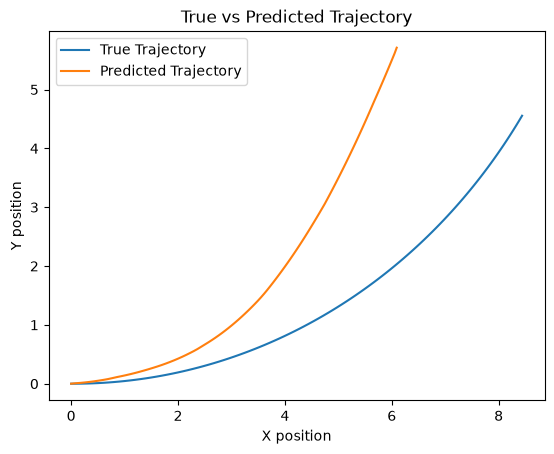

In [286]:
# Test your implementation:
x_true, x_pred, average_loss = test_dynamics_model()
print(f'Average loss {average_loss:.4f}')

plt.figure()
plt.plot([x[0] for x in x_true], [x[1] for x in x_true], label='True Trajectory')
plt.plot([x[0] for x in x_pred], [x[1] for x in x_pred], label='Predicted Trajectory')
plt.xlabel('X position')
plt.ylabel('Y position')
plt.title('True vs Predicted Trajectory')
plt.legend()
plt.show()